In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
df = pd.read_csv("infection_data.csv")

In [3]:
df.head()

,day,pfemp_variant_frac,infection_id,start_day,duration,total_gametocyte_density,human_id
0,85,0.025234,0,85,165,3284.959044,0
1,52,0.000000,1,52,264,1727.666964,0
2,48,0.000000,2,48,399,3496.682096,0
3,251,0.058879,3,251,206,4173.975590,0
4,323,0.077570,4,323,226,4113.914762,0


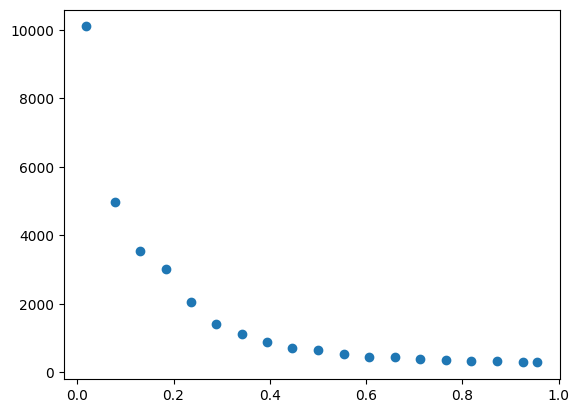

In [4]:
# Bin pfemp_variant_frac into 100 bins and count number of infections in each bin
bins = np.linspace(0, 1, 20)
df['bin'] = np.digitize(df['pfemp_variant_frac'], bins)
df['bin'].value_counts()

# scatter plot bin mean vs number of counts in bin
bin_counts = df['bin'].value_counts()
bin_means = df.groupby('bin')['pfemp_variant_frac'].mean()
plt.scatter(bin_means, bin_counts)

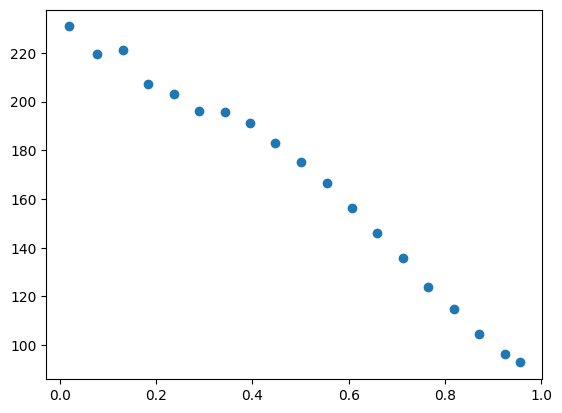

In [5]:
# Get mean duration for all infections in each bin
bin_duration_means = df.groupby('bin')['duration'].mean()
plt.scatter(bin_means, bin_duration_means)

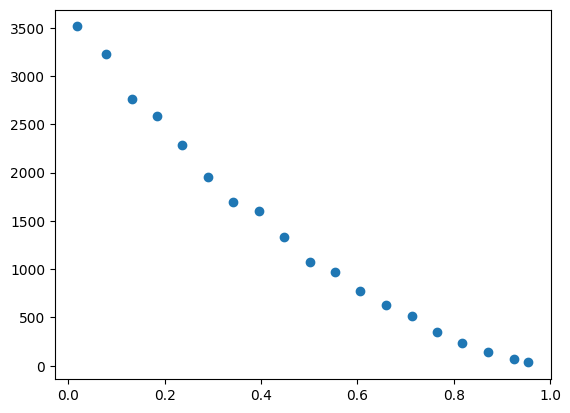

In [6]:
# Get mean total_gametocyte_density for all infections in each bin
bin_tgd_means = df.groupby('bin')['total_gametocyte_density'].mean()
plt.scatter(bin_means, bin_tgd_means)

[-149.12502686] 240.85719560771392


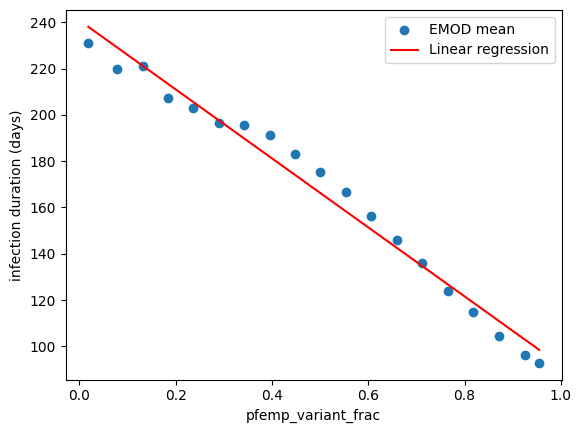

In [7]:
# Fit a linear model to the bin_means vs bin_duration_means
from sklearn.linear_model import LinearRegression
model = LinearRegression()
X = bin_means.values.reshape(-1, 1)
y = bin_duration_means.values
model.fit(X, y)
plt.scatter(bin_means, bin_duration_means, label="EMOD mean")
plt.plot(bin_means, model.predict(X), color='red', label="Linear regression")
plt.legend()
plt.xlabel('pfemp_variant_frac')
plt.ylabel('infection duration (days)')

# Print the slope and offset of the model
print(model.coef_, model.intercept_)

# Verify that the model coefficients mean what we think they mean
# plt.plot(bin_means, model.coef_ * bin_means + model.intercept_, color='green', linestyle='dashed')

[    0.         -6409.78868457  2767.16784511] 3635.056354968346


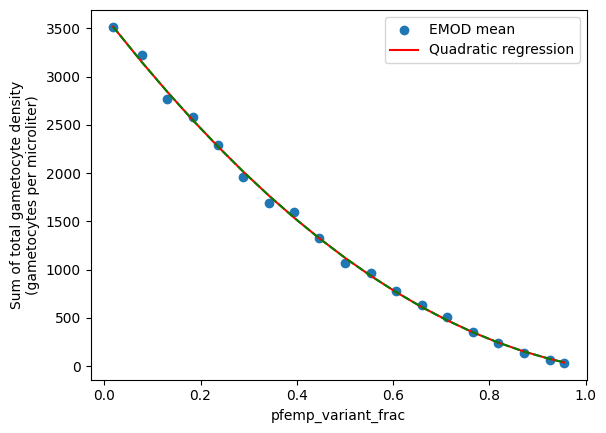

In [8]:
# Fit a quadratic model to the bin_means vs total_gametocyte_density
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2)
X = poly.fit_transform(bin_means.values.reshape(-1, 1))
y = bin_tgd_means.values
model = LinearRegression()
model.fit(X, y)
plt.scatter(bin_means, bin_tgd_means, label="EMOD mean")
plt.plot(bin_means, model.predict(X), color='red', label="Quadratic regression")
plt.legend()
plt.xlabel('pfemp_variant_frac')
plt.ylabel('Sum of total gametocyte density\n(gametocytes per microliter)')

# Print the coefficients of the model
print(model.coef_, model.intercept_)

# Verify that the model coefficients mean what we think they mean
plt.plot(bin_means, model.coef_[2] * bin_means**2 + model.coef_[1] * bin_means + model.intercept_, color='green', linestyle='dashed')

In [9]:
model.coef_[2] * 0.98**2 + model.coef_[1] * 0.98 + model.intercept_

11.051442539283016

# Trying to fit variances

<ErrorbarContainer object of 3 artists>

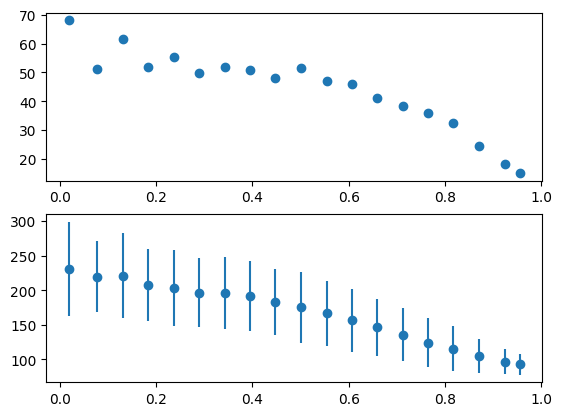

In [15]:
# Get mean duration for all infections in each bin
bin_duration_std = df.groupby('bin')['duration'].std()

plt.figure()
plt.subplot(211)
plt.scatter(bin_means, bin_duration_std)

plt.subplot(212)
plt.errorbar(bin_means, bin_duration_means, yerr=bin_duration_std, fmt='o')

<ErrorbarContainer object of 3 artists>

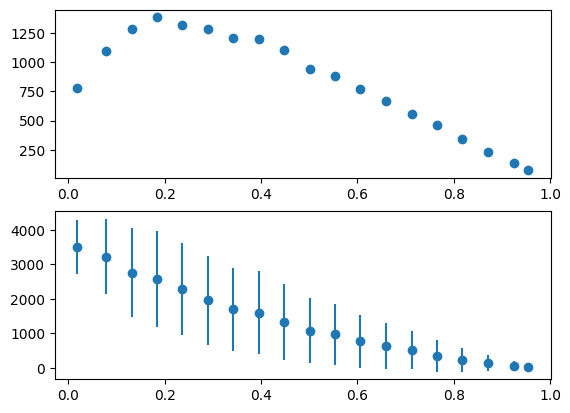

In [16]:
# Do same for total_gametocyte_density
bin_tgd_std = df.groupby('bin')['total_gametocyte_density'].std()

plt.figure()
plt.subplot(211)
plt.scatter(bin_means, bin_tgd_std)

plt.subplot(212)
plt.errorbar(bin_means, bin_tgd_means, yerr=bin_tgd_std, fmt='o')

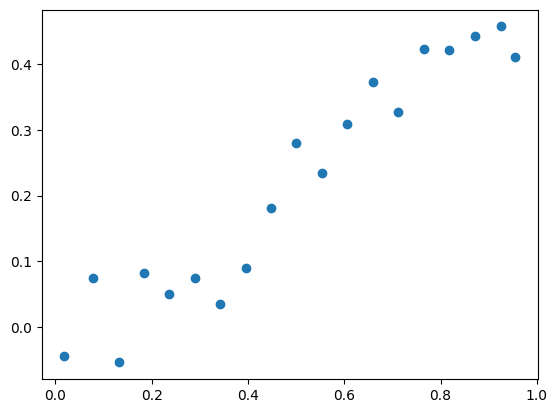

In [17]:
# Correlation between duration and total_gametocyte_density, by bin
bin_duration_tgd_corr = df.groupby('bin')[['duration', 'total_gametocyte_density']].corr().iloc[0::2,-1]
plt.scatter(bin_means, bin_duration_tgd_corr)


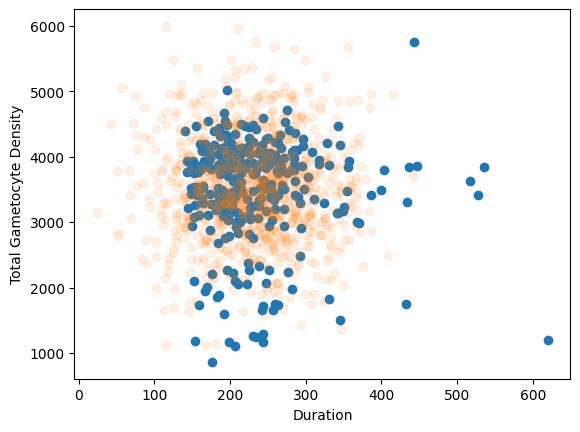

In [40]:
# Directly scatter plot duration and total_gametocyte_density for a bin
bin_num = 1
plt.scatter(df[df['bin'] == bin_num]['duration'], df[df['bin'] == bin_num]['total_gametocyte_density'])

# Fit a simple multivariate Gaussian distribution using the mean, stdev, and correlations in this bin
mean = np.array([bin_duration_means[bin_num], bin_tgd_means[bin_num]])
cov = np.array([[bin_duration_std[bin_num]**2, bin_duration_tgd_corr[bin_num].values[0] * bin_duration_std[bin_num] * bin_tgd_std[bin_num]],
                [bin_duration_tgd_corr[bin_num].values[0] * bin_duration_std[bin_num] * bin_tgd_std[bin_num], bin_tgd_std[bin_num]**2]])

# Sample from this distribution and plot
samples = np.random.multivariate_normal(mean, cov, 1000)
plt.scatter(samples[:,0], samples[:,1], alpha=0.1)
plt.xlabel('Duration')
plt.ylabel('Total Gametocyte Density')
plt.show()


[5.40665825 0.2552259 ]


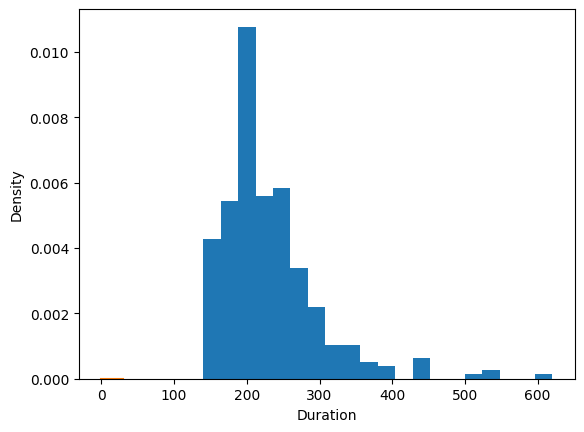

[8.13037574 0.28556451]


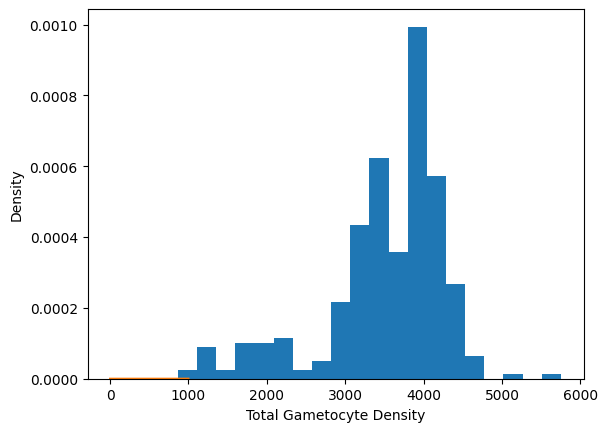

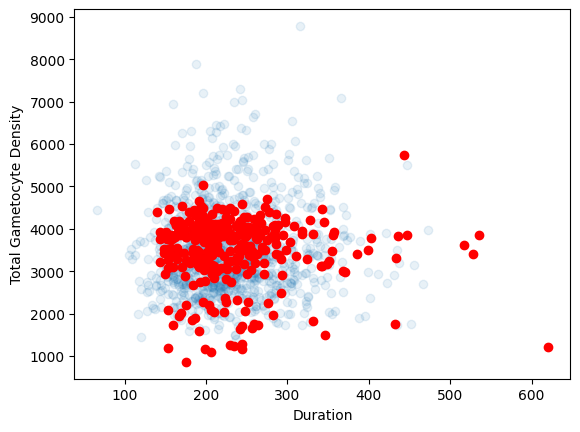

In [44]:
# Fit a log-normal distribution to both the duration and total_gametocyte_density, respecting the correlation
from scipy.stats import lognorm
from scipy.optimize import minimize

def lognorm_pdf(x, mean, std):
    return lognorm.pdf(x, s=std, scale=np.exp(mean))

def lognorm_ll(params, data):
    mean, std = params
    return -np.sum(np.log(lognorm_pdf(data, mean, std)))

def lognorm_fit(data):
    res = minimize(lognorm_ll, [np.mean(np.log(data)), np.std(np.log(data))], args=(data))
    return res.x

# Fit log-normal to duration
duration_params = lognorm_fit(df[df['bin'] == bin_num]['duration'])
print(duration_params)
plt.hist(df[df['bin'] == bin_num]['duration'], bins=20, density=True)
x = np.linspace(0, 30, 100)
plt.plot(x, lognorm_pdf(x, *duration_params))
plt.xlabel('Duration')
plt.ylabel('Density')
plt.show()

# Fit log-normal to total_gametocyte_density
tgd_params = lognorm_fit(df[df['bin'] == bin_num]['total_gametocyte_density'])
print(tgd_params)

plt.hist(df[df['bin'] == bin_num]['total_gametocyte_density'], bins=20, density=True)
x = np.linspace(0, 1000, 100)
plt.plot(x, lognorm_pdf(x, *tgd_params))
plt.xlabel('Total Gametocyte Density')
plt.ylabel('Density')
plt.show()

# Sample from these distributions and plot
samples_duration = np.random.lognormal(*duration_params, 1000)
samples_tgd = np.random.lognormal(*tgd_params, 1000)
plt.scatter(samples_duration, samples_tgd, alpha=0.1)
plt.xlabel('Duration')
plt.ylabel('Total Gametocyte Density')

# Plot the original data
plt.scatter(df[df['bin'] == bin_num]['duration'], df[df['bin'] == bin_num]['total_gametocyte_density'], color='red')
plt.show()

In [30]:
bin_duration_std[bin_num]

51.587326405065944

In [36]:
bin_duration_tgd_corr[bin_num].values[0]

0.27928861922684856

In [32]:
bin_duration_tgd_corr[bin_num] * bin_duration_std[bin_num] * bin_tgd_std[bin_num]

duration    13639.755872
Name: total_gametocyte_density, dtype: float64

In [27]:
mean

array([ 175.35837246, 1073.05697905])

In [28]:
cov

[[2661.252245622814,
  duration    13639.755872
  Name: total_gametocyte_density, dtype: float64],
 [duration    13639.755872
  Name: total_gametocyte_density, dtype: float64,
  896232.4733987398]]